# Homework12

Exercises with Neural Networks

## Goals

- Get familiar with neural network setup, design, data preparation and training process
- Practice setting up the ingredients and parameters for the training loop
- Experiment with neural networks for classification tasks


### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/nn_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/imagenette.tar.gz | tar xz

In [2]:
from os import listdir
from PIL import Image as PImage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from torch import nn, Tensor
from torch.optim import Adagrad, Adam, SGD

from data_utils import classification_error, display_confusion_matrix
from image_utils import get_pixels

from nn_utils import get_labels, get_num_params

## Neural Networks and Classification

We've set up neural networks for regression and classification in the [WK11](https://github.com/PSAM-5020-2026S-A/WK11) and [WK12](https://github.com/PSAM-5020-2026S-A/WK12) notebooks.

The steps for training a neural network are similar to all of the ML processes we've seen so far:
- Data split
- Data pre-preprocessing
- Training/Fitting
- Validation

The specific steps for training a classification network are:

- Load dataset and do any kind of pre-pre-processing (like get pixels and labels for each image)
- Split data into train/test datasets
- Perform any kind of pre-processing (like scaling or encoding)
- Load features and labels into `Tensors`
- Build a NN model
- Set up an optimizer
- Pick a cost/loss function
- Implement an evaluation function and any other kind of visualization that helps quantify/evaluate the model
- Train model
- Evaluate

### Start with the Data

As always, we start with the data. 

We're using the `imagenette` datasets, which is a small subset of the [ImageNet](https://www.image-net.org/) dataset. ImageNet has millions of images and $10\text{,}000$ classes. The `imagenette` subset has about $5\text{,}000$ images that we'll classify into $10$ classes.

The dataset is already split into two directories with training and testing datasets.

The following cell creates file lists for the training and test datasets.

In [3]:
TRAIN_DIR = "./data/image/imagenette/train"
TEST_DIR = "./data/image/imagenette/test"

train_files = sorted(fname for fname in listdir(TRAIN_DIR) if fname.endswith("jpg"))
test_files = sorted(fname for fname in listdir(TEST_DIR) if fname.endswith("jpg"))

### Extract Features

We have to go through the files and extract labels and pixels for each image.

Pixels can be extracted with the `getdata()` function of `PIL.Image` objects or the `get_pixels()` function from our `image_utils` library.

The images are in color. We can either convert them to grayscale, or extract $3$ separate images, one from each channel, and then combine them sequentially. The `img.split()` function might help with the second strategy.

The label for each file can be extracted by reading the first item after splitting the filename on `_`.

These eventually have to be encoded into whole numbers.

In [4]:
train_pixels = []
train_labels = []

for fname in train_files:
    # extract label from filename (first part before "_")
    label = fname.split("_")[0]
    train_labels.append(label)
    
    # open image and extract pixels
    img = PImage.open(f"{TRAIN_DIR}/{fname}")
    pixels = get_pixels(img)
    train_pixels.append(pixels)

test_pixels = []
test_labels = []

for fname in test_files:
    label = fname.split("_")[0]
    test_labels.append(label)
    
    img = PImage.open(f"{TEST_DIR}/{fname}")
    pixels = get_pixels(img)
    test_pixels.append(pixels)

# check what we got
print("Train samples:", len(train_pixels))
print("Test samples: ", len(test_pixels))
print("Pixel length: ", len(train_pixels[0]))
print("Unique labels:", sorted(set(train_labels)))

Train samples: 3000
Test samples:  1500
Pixel length:  16384
Unique labels: ['chainsaw', 'church', 'dog', 'fish', 'golf', 'horn', 'parachute', 'pump', 'soundsystem', 'truck']


### Tensor It !

Once we have `pixel` and `label` lists, we can create our `Tensor` objects.

Here we're casting label `Tensor`s to `long()` to convert them to whole numbers instead of keeping them as floats.

In [5]:
# get unique labels and encode them as numbers
unique_labels = sorted(set(train_labels))
label_to_int = {label: i for i, label in enumerate(unique_labels)}

print("Label encoding:", label_to_int)

# encode labels to integers
train_labels_encoded = [label_to_int[l] for l in train_labels]
test_labels_encoded = [label_to_int[l] for l in test_labels]

# package into dicts to match homework format
train = {"pixels": train_pixels, "labels": train_labels_encoded}
test = {"pixels": test_pixels, "labels": test_labels_encoded}

# now create Tensors
x_train = Tensor(train["pixels"])
y_train = Tensor(train["labels"]).long()
x_test = Tensor(test["pixels"])
y_test = Tensor(test["labels"]).long()

print(len(x_train), len(x_test), x_train.shape, x_test.shape)

Label encoding: {'chainsaw': 0, 'church': 1, 'dog': 2, 'fish': 3, 'golf': 4, 'horn': 5, 'parachute': 6, 'pump': 7, 'soundsystem': 8, 'truck': 9}
3000 1500 torch.Size([3000, 16384, 3]) torch.Size([1500, 16384, 3])


### Let's train !

Let's create a single layer neural network, like the first one from class, and train it with the training data.

In addition to the actual model/network, we also need an optimizer and a loss function.

In [6]:
import torch

# flatten the color channels: [samples, 16384, 3] -> [samples, 49152]
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print("x_train shape after flatten:", x_train.shape)  # [3000, 49152]
print("x_test shape after flatten: ", x_test.shape)   # [1500, 49152]

# scale the pixel values
scaler = StandardScaler()
x_train = Tensor(scaler.fit_transform(x_train))
x_test = Tensor(scaler.transform(x_test))

# model parameters
num_inputs = x_train.shape[1]  # 49152
num_outputs = 10                # 10 classes

# TODO: Create the model — single layer network
model = nn.Sequential(
    nn.Linear(num_inputs, num_outputs)
)

# TODO: Create the optimizer
optimizer = Adam(model.parameters(), lr=0.001)

# loss function (already defined in homework)
loss_fn = nn.CrossEntropyLoss()

print("\nModel:", model)
print("Num params:", get_num_params(model))

x_train shape after flatten: torch.Size([3000, 49152])
x_test shape after flatten:  torch.Size([1500, 49152])

Model: Sequential(
  (0): Linear(in_features=49152, out_features=10, bias=True)
)
Num params: 491530


### Question

<span style="color:hotpink;">
How many parameters does your model have?<br>
How many input features does the model have?<br>
How many output features?<br>
</span>

<span style="color:hotpink;">How many parameters does your model have?

491,530 parameters. 

How many input features does the model have?

49,152 input features — one for each pixel value across all 3 color channels 

How many output features?

10 output features — one for each image class: chainsaw, church, dog, fish, golf, horn, parachute, pump, soundsystem, and truck.</span>

### The Loop

Create a training loop like we saw in class.

This loop should:
- Predict classes by feeding all of the inputs into the `model`
- Measure `loss` (this is just `loss_fn(predicted, actual)`)
- Get the optimizer to back-propagate and annotate the neurons
- Update parameters

The loop should be repeated as long as the loss keeps improving, and it doesn't look like the model is overfitting with the training data.

In order to check if the model is overfitting, we can sporadically run evaluations within the training loop in order to see if the model performs similarly with `train` and `test` data.

But ! Our network actually outputs a series of values for each image that we give it. In order to determine the exact class number of its predictions, we have to find the index of the output neuron with the largest value, which is an operation called `argmax()` (similar to `argsort()` from week 10).

It's not hard to do this manually, but we can use the `get_labels(model, inputs)` function inside the `nn_utils` file to run our `model` on all of the data in a given dataset and return the predicted labels for all of the samples.

In [ ]:
# TODO: iterate epochs
num_epochs = 1000

for epoch in range(num_epochs):
    # TODO: predict
    predicted = model(x_train)
    
    # TODO: measure loss
    loss = loss_fn(predicted, y_train)
    
    # TODO: compute gradient and step optimizer
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # TODO: show progress every 100 epochs
    if epoch % 100 == 0:
        # get predicted labels for train and test
        train_pred = get_labels(model, x_train)
        test_pred = get_labels(model, x_test)
        
        train_error = classification_error(y_train, train_pred)
        test_error = classification_error(y_test, test_pred)
        
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Train error: {train_error:.3f} | Test error: {test_error:.3f}")

### Evaluate

This should be similar to the last error values seen during training, but sometimes it changes a bit...

Not a bad idea to check the accuracy of the model using the `classification_error()` function, and look at some confusion matrices.

Train error: 0.9186666666666666
Test error:  0.912

--- Train Confusion Matrix ---

--- Test Confusion Matrix ---


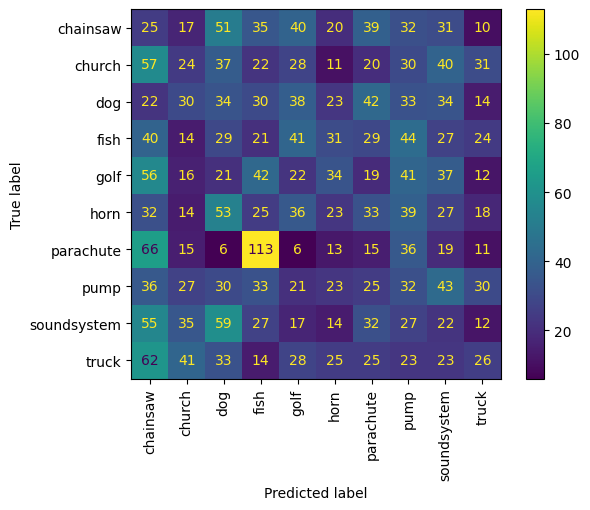

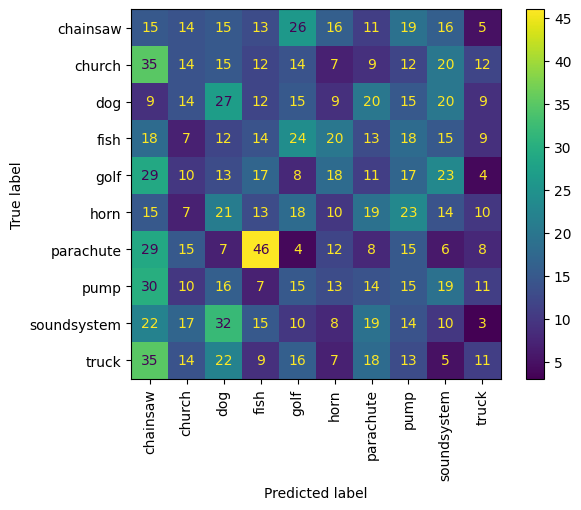

In [7]:
# get final predictions
train_pred = get_labels(model, x_train)
test_pred = get_labels(model, x_test)

# TODO: classification error for train and test data
print("Train error:", classification_error(y_train, train_pred))
print("Test error: ", classification_error(y_test, test_pred))

# TODO: confusion matrices for train and test data
print("\n--- Train Confusion Matrix ---")
display_confusion_matrix(y_train, train_pred, unique_labels)

print("\n--- Test Confusion Matrix ---")
display_confusion_matrix(y_test, test_pred, unique_labels)

### Interpretation

<span style="color:hotpink;">
What's going on ? Is the network learning ?
</span>

<span style="color:hotpink;">The network is learning the training data extremely well. Train error dropped from 72.9% to just 0.7% in 100 epochs. However, test error barely moved. This massive gap between train error (0.7%) and test error (71.5%) is a sign of severe overfitting I think. It is memorizing the train data but not generalizing well.</span>

## Neural Networks and PCA

We are seeing how Neural Networks can be _easy_ to build and explain in generic/abstract terms (a bunch of little operators that perform weighted sums of their inputs), but in reality can be really difficult and opaque to steer.

In theory, a couple of well placed neuron layers, with the right hyperparameters, learning rate, loss function, architecture and a good amount of data, can learn to extract information like polynomial features, clusters or even PCA components. But... that's not always the case and sometimes it's not a bad idea to *encourage* the network to go down a certain path.

One way to do this is to pre-process our inputs and do a bit of feature extraction ourselves.

Let's see if we can improve this classification network by using PCA information instead of pixel data.

### Add PCA

We're going to repeat the training, but this time our data is going to be scaled and PCA'd before going into the neural network.

So, the data preparation flow should be:
- Scale data for `PCA`
- Perform `PCA`

We need one `StandardScaler()` object and one `PCA()` object.

The `train` data goes through the `fit_transform()` function of these objects, while the `test` data only goes through `transform()`.

For the `PCA`, we can aim for an explained variance of around $80\%$. This should reduce the number of features significantly to allow us to experiment with our network architecture.

We're working with a dataset that is $3\text{,}000$ rows by $49\text{,}152$ columns. Fitting `PCA` can take a minute.

In [8]:
# TODO: Scale
pca_scaler = StandardScaler()

# convert to numpy if needed
x_train_np = x_train.numpy() if hasattr(x_train, 'numpy') else x_train
x_test_np = x_test.numpy() if hasattr(x_test, 'numpy') else x_test

x_train_scaled = pca_scaler.fit_transform(x_train_np)
x_test_scaled = pca_scaler.transform(x_test_np)
print("Scaling done...")

# TODO: PCA — use fixed number of components instead of 0.80 to save memory
image_pca = PCA(n_components=100)
x_train_pca = image_pca.fit_transform(x_train_scaled)
x_test_pca = image_pca.transform(x_test_scaled)

print(f"PCA done! Components: {image_pca.n_components_}")
print(f"Explained variance: {sum(image_pca.explained_variance_ratio_):.3f}")

# TODO: Tensors
x_train_t = Tensor(x_train_pca)
x_test_t = Tensor(x_test_pca)

print("x_train_t shape:", x_train_t.shape)
print("x_test_t shape: ", x_test_t.shape)

Scaling done...
PCA done! Components: 100
Explained variance: 0.802
x_train_t shape: torch.Size([3000, 100])
x_test_t shape:  torch.Size([1500, 100])


### Repeat

Re-create model, optimizer, loss function, then re-run the training loop and evaluate.

Model: Sequential(
  (0): Linear(in_features=100, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)
Num params: 21834
Epoch    0 | Loss: 3.7063 | Train error: 0.891 | Test error: 0.895
Epoch  100 | Loss: 0.5301 | Train error: 0.109 | Test error: 0.645
Epoch  200 | Loss: 0.0495 | Train error: 0.001 | Test error: 0.645
Epoch  300 | Loss: 0.0123 | Train error: 0.000 | Test error: 0.651
Epoch  400 | Loss: 0.0057 | Train error: 0.000 | Test error: 0.653
Epoch  500 | Loss: 0.0033 | Train error: 0.000 | Test error: 0.656
Epoch  600 | Loss: 0.0022 | Train error: 0.000 | Test error: 0.651
Epoch  700 | Loss: 0.0015 | Train error: 0.000 | Test error: 0.649
Epoch  800 | Loss: 0.0011 | Train error: 0.000 | Test error: 0.650
Epoch  900 | Loss: 0.0009 | Train error: 0.000 | Test error: 0.649

Final Train error: 0.0
Final Test error:  0.6493333333333333

--- Train Confusion Mat

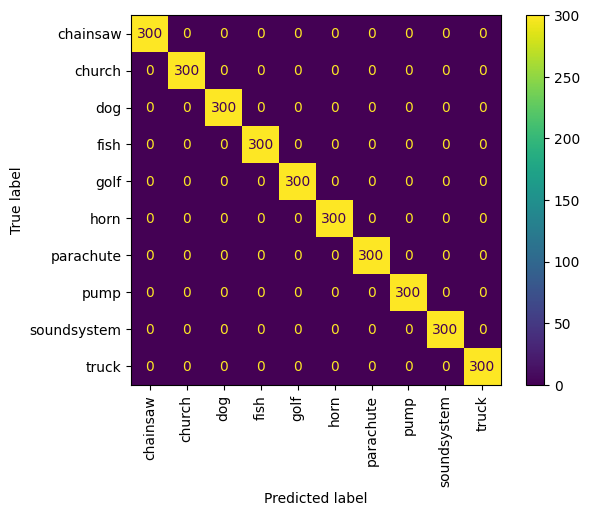

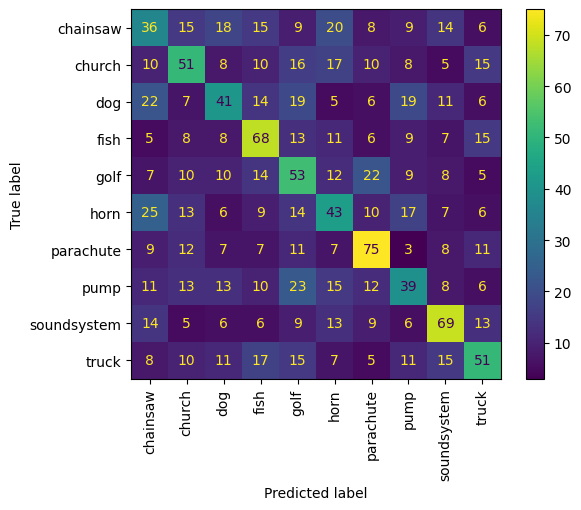

In [9]:
# TODO: Model, Optimizer and Loss Function
num_inputs_pca = x_train_t.shape[1]  # number of PCA components
num_outputs = 10                       # 10 classes

model_pca = nn.Sequential(
    nn.Linear(num_inputs_pca, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_outputs)
)

optimizer_pca = Adam(model_pca.parameters(), lr=0.001)
loss_fn_pca = nn.CrossEntropyLoss()

print("Model:", model_pca)
print("Num params:", get_num_params(model_pca))

# TODO: Training loop
num_epochs = 1000

for epoch in range(num_epochs):
    predicted = model_pca(x_train_t)
    loss = loss_fn_pca(predicted, y_train)
    
    optimizer_pca.zero_grad()
    loss.backward()
    optimizer_pca.step()
    
    if epoch % 100 == 0:
        train_pred = get_labels(model_pca, x_train_t)
        test_pred = get_labels(model_pca, x_test_t)
        
        train_error = classification_error(y_train, train_pred)
        test_error = classification_error(y_test, test_pred)
        
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Train error: {train_error:.3f} | Test error: {test_error:.3f}")

# TODO: Evaluation
train_pred = get_labels(model_pca, x_train_t)
test_pred = get_labels(model_pca, x_test_t)

print("\nFinal Train error:", classification_error(y_train, train_pred))
print("Final Test error: ", classification_error(y_test, test_pred))

print("\n--- Train Confusion Matrix ---")
display_confusion_matrix(y_train, train_pred, unique_labels)

print("\n--- Test Confusion Matrix ---")
display_confusion_matrix(y_test, test_pred, unique_labels)

### Interpretation

<span style="color:hotpink;">
So... What happens ?<br>
How does training on the <code>PCA</code> data compare to training on the regular data ?

What else does <code>PCA</code> afford us in this case ? ...<br>
How does adding extra layers in the original network compare to adding extra layers in the <code>PCA</code> network?
</span>

<span style="color:hotpink;">The PCA network performs better than the raw pixel network (65% vs 71.5% test error) and is 22x smaller (21,834 vs 491,530 parameters), which prevented the kernel from crashing. Both models still overfit heavily. Train error hits 0% while test error plateaus around 65%. But the PCA version is more stable and doesn't keep getting worse after epoch 100. It seems like the biggest advantage of PCA is it compresses 49,152 pixel inputs down to 100 meaningful features, making it actually possible to experiment with deeper network structures without running out of memory.</span>